<a href="https://colab.research.google.com/github/AllenSWDB/TReND-CaMinA/blob/main/notebooks/Kenya26/03-04-AllenTutorial/Session_2_Compare_neurons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
<h3> This notebook will compare tuning curves of different neurons using the Allen Brain Observatory data </h3>
    
In the first notebook, we computed the tuning curve of one neuron to the 'Drifting Gratings' stimulus. Here we will do this for many neurons so we can see the diversity of visual responses.


In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Allen Brain Observatory set up

In [ ]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [ ]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:  
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X 
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p>In the last notebook we walked through computing the two dimensional tuning curve for just one neuron. Here we are going to do this for many neurons. I'm providing a function that walks through all the steps we did in notebook 1, but does it in parallel for all neurons from one session. It load the data, computes the 2D tuning array, subtracts the blank sweep response, and makes a plot (I use dataframes to store this rather than numpy arrays because it is easier for working with this scale of data).
</div>

In [17]:
def compute_tuning(session_id):
    """
    Computes the 2D tuning array for all neurons in a given session
    for drifting gratings stimulus.

    Parameters
    ----------
    session_id : int
        The session id for one session.

    Returns
    -------
    dff : numpy.ndarray
        Delta F over F traces for all cells.
    stim_table : pandas.DataFrame
        Stimulus table for drifting gratings.
    trial_response : pandas.DataFrame
        Response per trial for all neurons.
    tuning_array : numpy.ndarray
        2D tuning array for all neurons, with dimensions (orientation, temporal_frequency, cell index).
    """
    #access data for the session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for all cells
    timestamps, dff = data_set.get_dff_traces()
    number_cells = dff.shape[0]
    print("Number of cells: ", number_cells)

    #get the stimulus table for the drifting gratings
    stim_table = data_set.get_stimulus_table('drifting_gratings')

    #get the orivals and tfvals
    all_ori = np.unique(stim_table.orientation)
    orivals = all_ori[np.isfinite(all_ori)]
    tfvals = np.unique(stim_table.temporal_frequency)
    tfvals = tfvals[np.isfinite(tfvals)]

    #compute response per trial for all neurons
    trial_response = pd.DataFrame(index=stim_table.index.values, columns=np.array(range(number_cells)).astype(str))

    for ind,row in stim_table.iterrows():
        for nc in range(number_cells):
            trial_response.loc[ind, str(nc)] = dff[nc,int(row.start):int(row.end)].mean()

    #calculate the response to the blanksweeps:
    blank_response = trial_response[np.isnan(stim_table.orientation)].mean()

    #compute 2D tuning array and subtract the blanksweep response
    tuning_array = np.empty((8,5,number_cells))
    for i,tf in enumerate(tfvals): #iterate across TF
        for j,ori in enumerate(orivals): #iterate across ori
            tuning_array[j,i,:] = trial_response[(stim_table.orientation==ori)&
                                                 (stim_table.temporal_frequency==tf)].mean() - blank_response

    return(dff, stim_table, trial_response, tuning_array)

Let's test this function by computing and plotting the tuning curve for the neuron we looked at in the preious notebook. To start, use the function above for session_id=540684467


In [45]:
(dff, stim_table, trial_response, tuning_array) = compute_tuning(540684467)

Number of cells:  290


First, let's look at the objects that we have. Let's start by examining their shape

In [19]:
dff.shape

(290, 115741)

In [20]:
stim_table.shape

(628, 5)

In [21]:
trial_response.shape

(628, 290)

In [22]:
tuning_array.shape

(8, 5, 290)

The DFF array now has the activity of ALL the neurons in this session, rather than just one.
<p> Another key difference here is that the trial_response is a pandas DataFrame. It has the same index as the stim_table, so each row is a trial, and each column is the mean response of one neuron. The columns are the index of the cells.
<p> Lastly, the tunning_array is now a 3-dimensional array, with dimensions orientation, temporal frequency, neurons.

The neuron we looked at in Notebook 1 has index=6 in these arrays. Let's look at the tuning curve we computed here and see if it matches what we got earlier.

In [ ]:
#Setting the axis values for all the tuning arrays
yvals = sorted(stim_table.orientation.dropna().unique())
xvals = sorted(stim_table.temporal_frequency.dropna().unique())

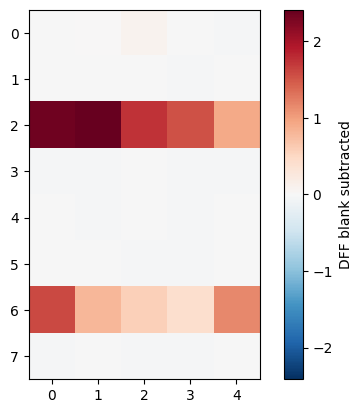

In [ ]:
plt.imshow(tuning_array[:,:,6], cmap='RdBu_r', vmax=tuning_array[:,:,6].max(), vmin=-1*tuning_array[:,:,6].max())
cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")

plt.xticks(np.arange(len(xvals)),xvals)
plt.yticks(np.arange(len(yvals)),yvals)
plt.xlabel("Temporal Frequency")
plt.ylabel("Orientation")
plt.show()


**Exercise 1:** Plot the tuning curves for a variety of neurons in this session. There are 290 neurons total, so just look at as many as you can.
<p> A few specific cells to try: 56, 181, 44, 258, 170, 120, 36, 98, 251, 272, 133
Try some others too!
<p> What are some of the differences you see among these neurons?

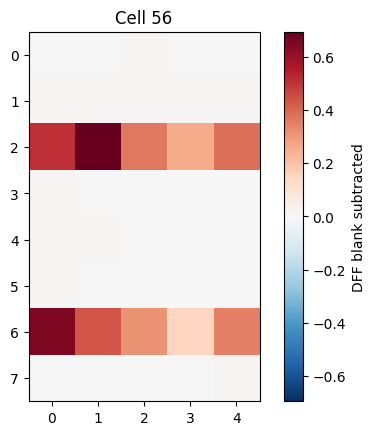

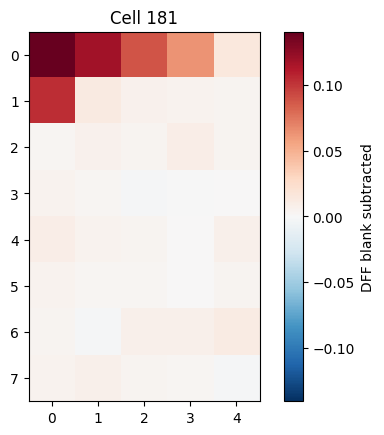

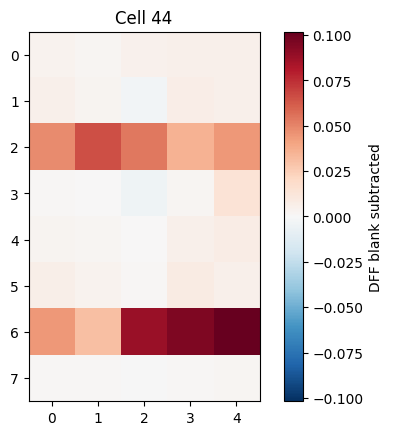

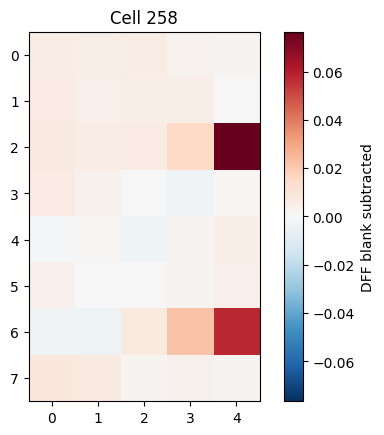

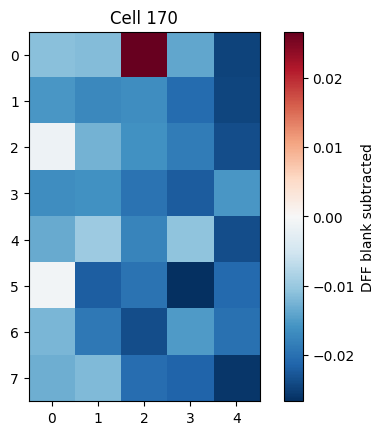

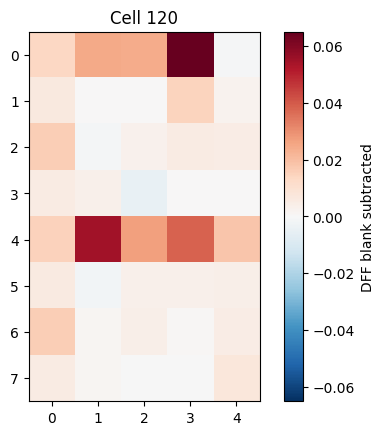

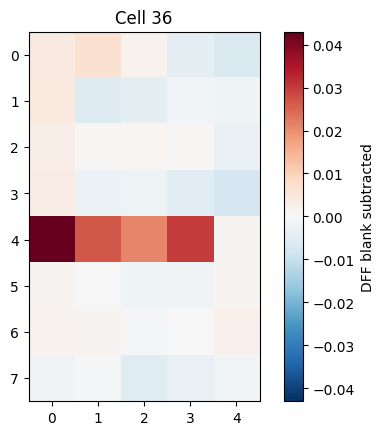

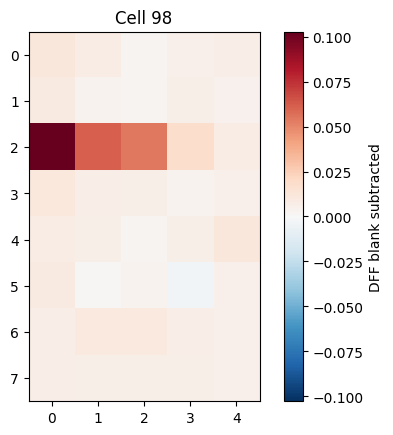

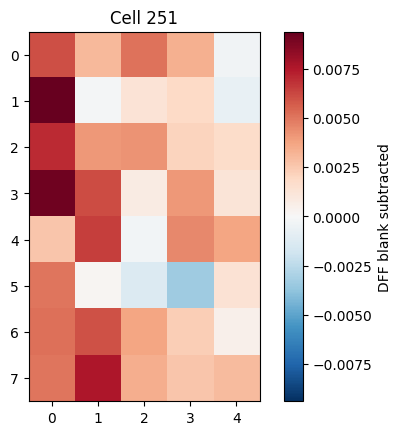

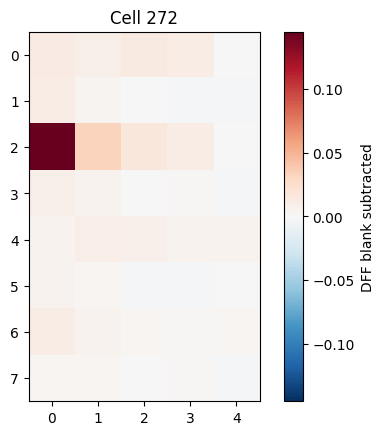

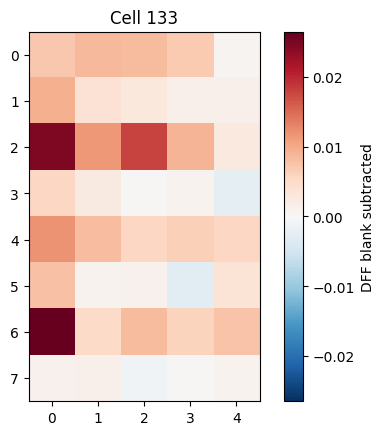

In [ ]:
#@title Click to see solution {display-mode: "form" }
for i in [56, 181, 44, 258, 170, 120, 36, 98, 251, 272, 133]:
  plt.imshow(tuning_array[:,:,i], cmap='RdBu_r', vmax=tuning_array[:,:,i].max(), vmin=-1*tuning_array[:,:,i].max())
  cbar = plt.colorbar()
  cbar.set_label("DFF blank subtracted")
  plt.xticks(np.arange(len(xvals)),xvals)
  plt.yticks(np.arange(len(yvals)),yvals)
  plt.xlabel("Temporal Frequency")
  plt.ylabel("Orientation")
  plt.title("Cell "+str(i))
  plt.show()

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
What are some things you notice when looking at these? What are some of the ways different neurons have different tuning curves?
</div>

Neurons can differ in which direction of motion they prefer, whether they are orientation selective (i.e. they respond ~equally to one direction and its opposite, thus responding to the orientation of the grating more than the direction of motion), respond broadly to many directions, or are slectively responsive to only one direction. Neurons can also differ in their temporal frequency tuning - which temporal frequency they have their preferred response to. Neurons also differ in the strength of their response. This can be both in terms of the absolute value of the response, but also the relative strength of the response (e.g. the difference between the response to the preferred condition and the response to non-preffered or blank sweep conditions). This can be measured in various ways and can be useful for determine the significance of the neuron's response. Does the neuron actually respond to this stimulus, or is the tuning really just noise?

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p>All of the neurons we've looked at so far are from just one session. This means they are all from a single population of neurons in a specific mouse, that has a specific genotype and age, and that were recorded from a single brain region and a single imaging depth (i.e. cortical layer).
<p>Let's see what these details are for this session. Begin by accessing the dataset for this session, starting with our orignal cell_id. We can use the same functions from the AllenSDK that are hidden in our get_dff_traces_and_stim_table function.
</div>

In [34]:
def print_metadata(session_id):
  """
  Prints metadata for a given ophys experiment session.

  Parameters
  ----------
  session_id : int
      The session id for one session.
  """
  data_set = boc.get_ophys_experiment_data(session_id)
  metadata = data_set.get_metadata()

  print("Mouse sex: ", metadata['sex'])
  print("Mouse age: ", metadata['age_days'])
  print("Mouse genotype: ", metadata["genotype"])
  print("Brain region: ", metadata["targeted_structure"])
  print("Imaging depth: ", metadata["imaging_depth_um"])

In [35]:
session_id = 540684467
print_metadata(session_id)

Mouse sex:  male
Mouse age:  121
Mouse genotype:  Emx1-IRES-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-GCaMP6f)/wt
Brain region:  VISp
Imaging depth:  175


What does this mean?
<p>We recorded from a male mouse in the brain region called "VISp". This is the primary visual cortex (sometimes called "V1").
<p>The imaging depth is 175 um, which maps to layer 2/3 of the cortex.
<p>And the genotype of the mouse is a jumble of letters. The first part "Emx1-IRES-Cre" is the Cre driver that is driving the expression of the reporter in a particular subset of neurons. In this case, Emx is a pan-excitatory driver, driving expression in all excitatory neurons, but not inhibitory interneurons. What is it driving? Camk2a-tTA and Ai93(TITL-GCaMP6f). Ai93 is GCaMP6f, a genetically encoded calcium indicator. Camk2a-tTA acts to amplify the expression of Ai93. In this mouse, all excitatory neurons in cortex are expressing GCaMP6f.
<p>So the neurons we are recording in this experiment are excitatory neurons in layer 2/3 of VISp.



---



In the entire Allen Brain Observatory dataset, we recorded from ~250 mice, sampling from **14 different transgenic lines, 6 cortical areas, and 4 different cortical layers**. This allows us to compare responses of neurons across all these dimensions. So let's compare these Emx responses we've been looking at above with some responses from neurons of other transgenic lines in VISp.
<p>The AllenSDK functions that we've been using to access our dataset allow us to use some of these metadata to identify sessions. Let's find sessions where neurons in VISp were recorded from other cell types.

We will look at responses from **Vip-IRES-Cre, Sst-IRES-Cre, and Pvalb-IRES-Cre**. These are three different types of inhibitory interneurons. As such they are much sparser than the Emx neurons are, so a given session often has a small number of neurons in it (say roughly a dozen) while the Emx session we were looking at before has over 200 neurons. We will just plot the tuning curves for all of the neurons in these experiments


We'll start by picking one session of `SST-IRES-Cre`, getting its session id, and then computing the tuning curve and plotting all cells

581150104
Number of cells:  8


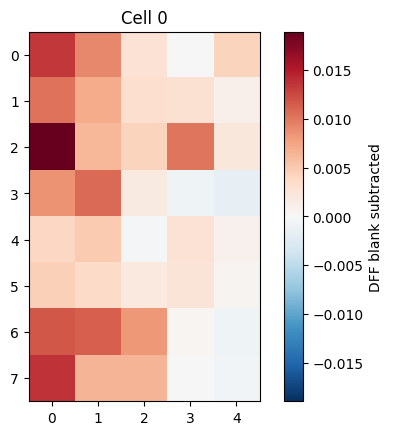

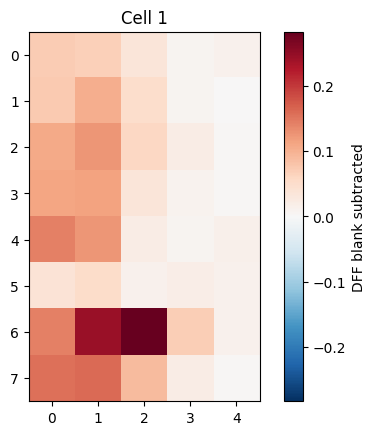

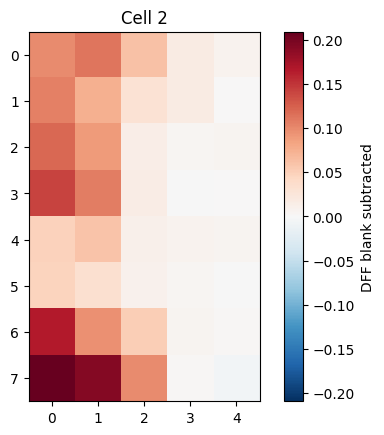

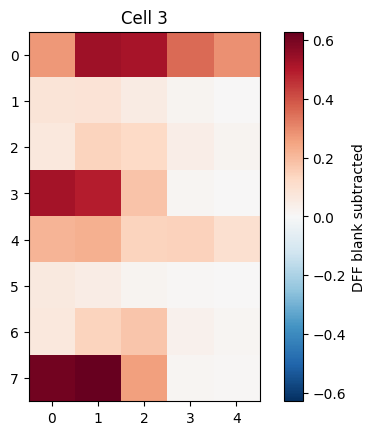

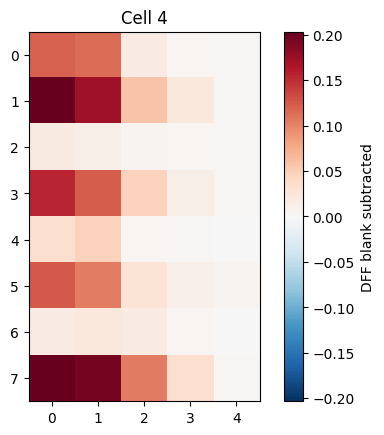

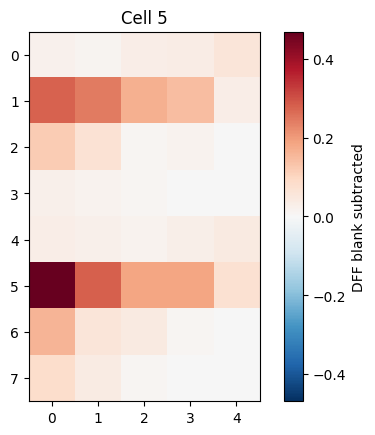

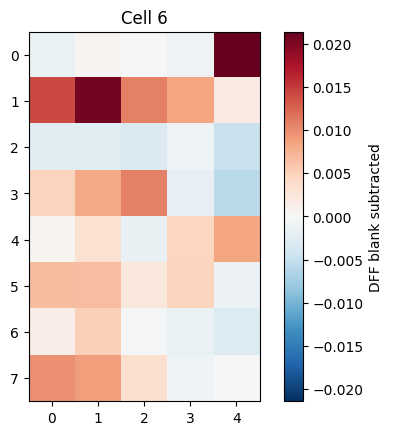

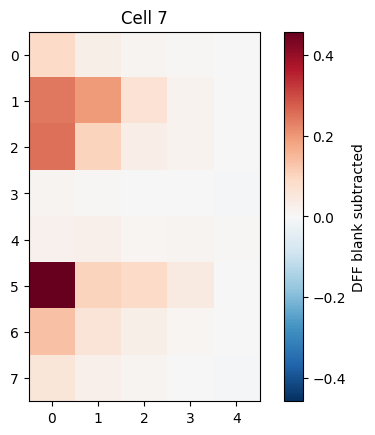

In [ ]:
#first we select a session with Sst-IRES-Cre in VISp when drifting gratings are presented. There are several such experiment and we'll just pull the first one (index 0).
session_id = boc.get_ophys_experiments(cre_lines=['Sst-IRES-Cre'], targeted_structures=['VISp'], stimuli=['drifting_gratings'])[0]['id']
print(session_id)

(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)
number_of_cells = dff.shape[0]
for i in range(number_of_cells):
  plt.imshow(tuning_array[:,:,i], cmap='RdBu_r', vmax=tuning_array[:,:,i].max(), vmin=-1*tuning_array[:,:,i].max())
  cbar = plt.colorbar()
  cbar.set_label("DFF blank subtracted")
  plt.xticks(np.arange(len(xvals)),xvals)
  plt.yticks(np.arange(len(yvals)),yvals)
  plt.xlabel("Temporal Frequency")
  plt.ylabel("Orientation")
  plt.title("Cell "+str(i))
  plt.show()



Repeat the same thing for `Pvalb-IRES-Cre`

673171528
Number of cells:  8


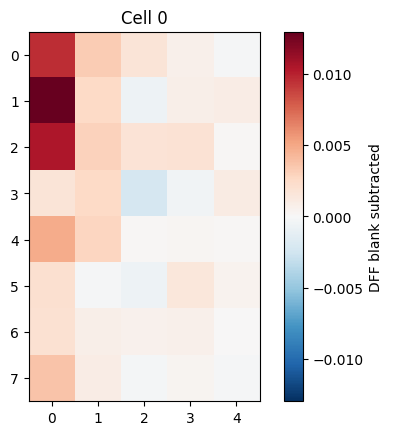

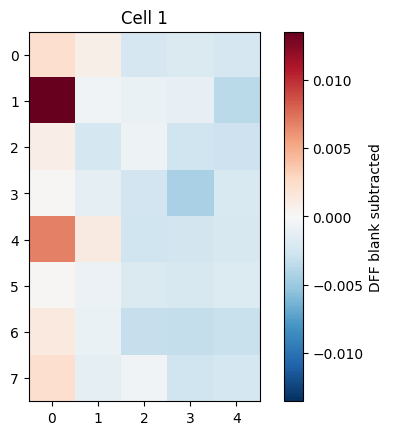

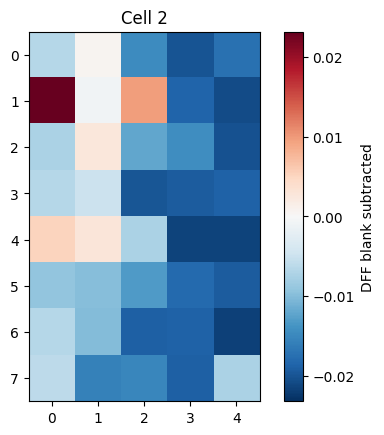

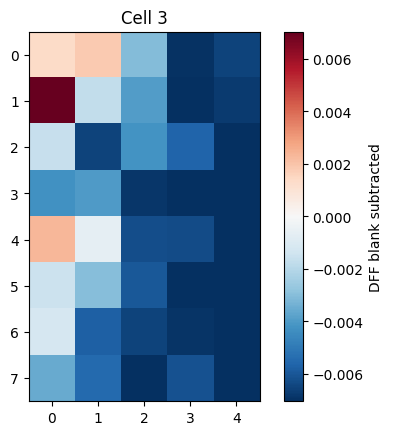

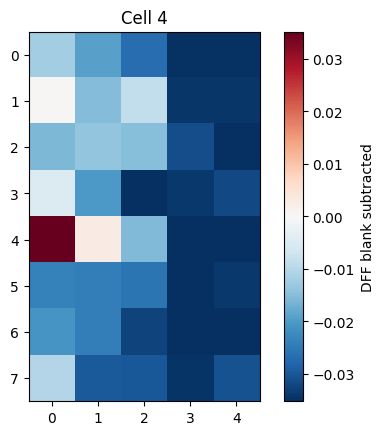

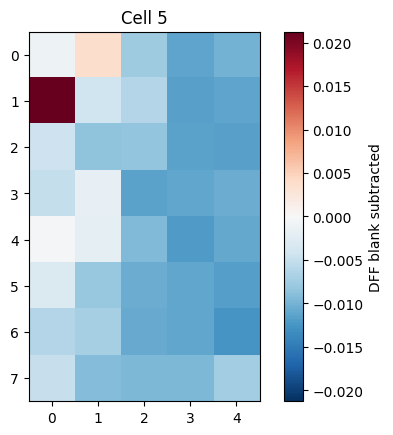

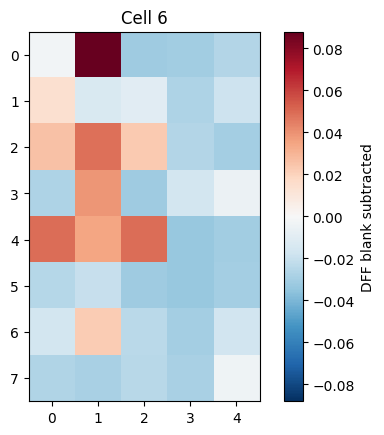

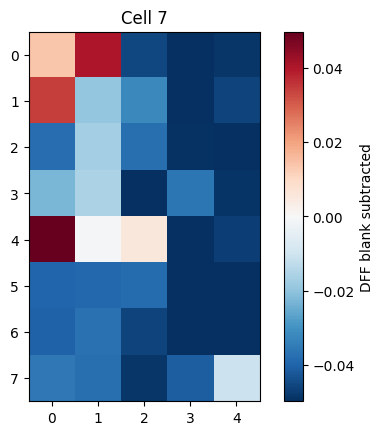

In [ ]:
session_id = boc.get_ophys_experiments(cre_lines=['Pvalb-IRES-Cre'], targeted_structures=['VISp'], stimuli=['drifting_gratings'])[0]['id']
print(session_id)

(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)
number_of_cells = dff.shape[0]
for i in range(number_of_cells):
  plt.imshow(tuning_array[:,:,i], cmap='RdBu_r', vmax=tuning_array[:,:,i].max(), vmin=-1*tuning_array[:,:,i].max())
  cbar = plt.colorbar()
  cbar.set_label("DFF blank subtracted")
  plt.xticks(np.arange(len(xvals)),xvals)
  plt.yticks(np.arange(len(yvals)),yvals)
  plt.xlabel("Temporal Frequency")
  plt.ylabel("Orientation")
  plt.title("Cell "+str(i))
  plt.show()

Repeat the same thing for `Vip-IRES-Cre`

657078119
Number of cells:  9


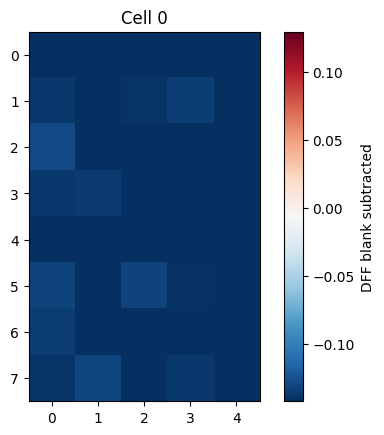

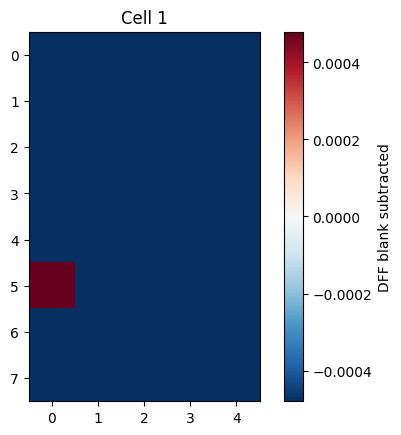

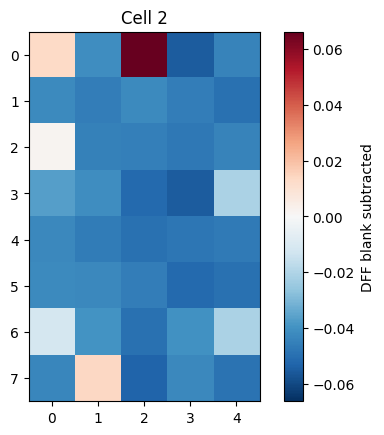

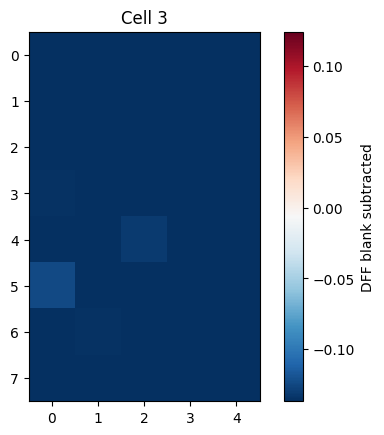

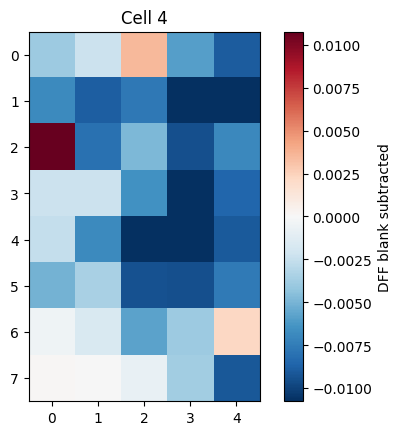

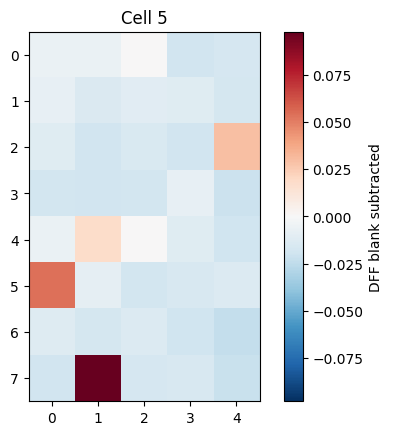

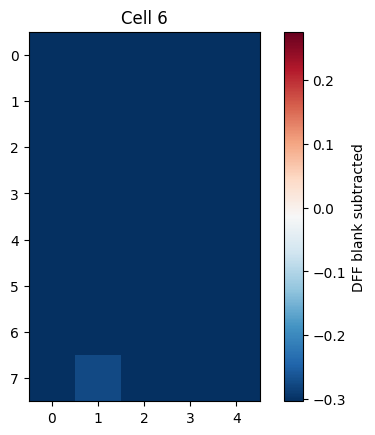

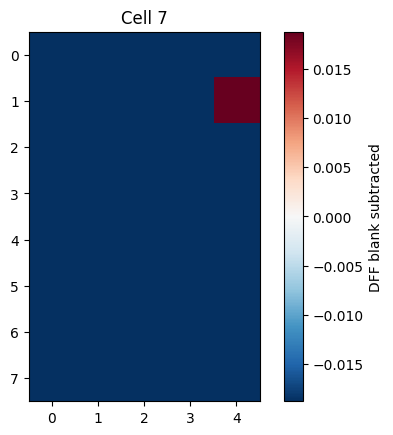

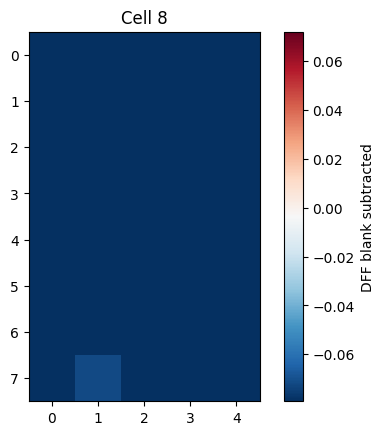

In [ ]:
session_id = boc.get_ophys_experiments(cre_lines=['Vip-IRES-Cre'], targeted_structures=['VISp'], stimuli=['drifting_gratings'])[2]['id']
print(session_id)

(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)
number_of_cells = dff.shape[0]
for i in range(number_of_cells):
  plt.imshow(tuning_array[:,:,i], cmap='RdBu_r', vmax=tuning_array[:,:,i].max(), vmin=-1*tuning_array[:,:,i].max())
  cbar = plt.colorbar()
  cbar.set_label("DFF blank subtracted")
  plt.xticks(np.arange(len(xvals)),xvals)
  plt.yticks(np.arange(len(yvals)),yvals)
  plt.xlabel("Temporal Frequency")
  plt.ylabel("Orientation")
  plt.title("Cell "+str(i))
  plt.show()

What do you notice about these tuning curves for the inhibitory interneurons? In what ways do they look similar to the Emx cells? In what ways do they look different? How consistent are the responses within each inhibitory population? Are the tuning curves of the different types of inhibitory interneurons similar to each other?